# Introduction to Gradient Descent Algorithm 

A convex function - in simple terms - can be explained as a function which is <b>"bowl shaped"</b>. The interesting thing about convex functions is that if you keep taking steps towards what feels as "lower ground" - lower value of that convex function - you are ultimately bound to reach the minimum. A property of convex functions is that if there exists a local minima - $w^*$ - it is also the global minimum - $w$. Due to this property, we can "greedily" use the <b>Gradient Descent</b> algorithm, and be sure that we are ultimately bound to reach the global mininimum.

In this blog post, we are going to explore three different approaches of Gradient Descent:
<ol>
    <li> Regular Gradient Descent 
    <li> Stochastic Gradient Descent
    <li> Stochastic Gradient Descent with Momentum 
</ol>

We will see how these three different approaches of Gradient Descent perform - how long they take to converge and find the minimum! Furthermore, we will also perform some experiments which will highlight some of the nuances of these approaches.

Here is an image of how a convex function looks, for visualization purposes: 

<center><img src="grad.jpg" width="400" height="400"/></center>

# Implementing Gradient Descent 

In [1]:
#implementing the necessary packages
from LogisticRegression import LogisticRegression
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt
import numpy as np

# logistic regression tends to involve a lot of log(0) and things that wash out in the end. 
np.seterr(all='ignore') 

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In the following section, we are using the *make_blobs* function of sklearn.datasets to create synthetic data for our experimentation. In this case, we are creating two clusters of data, which are centered around two different areas - and have different labels $0$ and $1$. These two clusters purposefully have overlap, and are not linearly separable. This means that one cannot imagine a straight line which perfectly divides the data points into two regions - one group or the other. 

In [2]:
#arbitrarily setting the seed number to 12345 to ensure reproducibility
np.random.seed(12345)

#setting the number of points we want
n = 200

#setting the number of features
features = 2

#using make_blobs function to create 2 clusters of 200 data points - centered   
#randomly around (-1,-1) and (1,1) - making them linearly inseparable 
X, y = make_blobs(n_samples = n, n_features = features, centers = [(-1,-1),(1,1)])

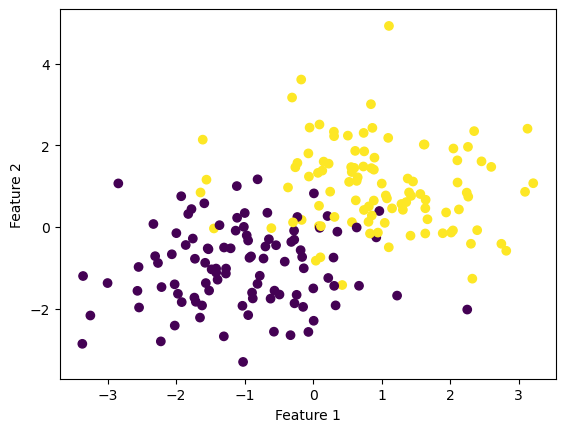

In [3]:
#plotting the clusters generated by the make_blobs function
fig = plt.scatter(X[:,0], X[:,1], c = y)
xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

In [4]:
#creating an instance of the LogisticRegression class
LR = LogisticRegression()

We are calling the <b>fit</b> method of the LogisticRegression class. This method uses the exponential loss function to calculate the loss, and updates the weight vector, using the <b>Gradient Descent</b> algorithm. The gradient function for the exponential loss function, has been borrowed from the <a href="https://middlebury-csci-0451.github.io/CSCI-0451/lecture-notes/gradient-descent.html"> lecture notes </a> on <b>Gradient Descent</b>!

In [5]:
LR.fit(X, y, 0.1, 1000)

For reference, the code had saved the first weight vector. Therefore, we can visualize how well the first linear classifier performed, and its associated loss. 

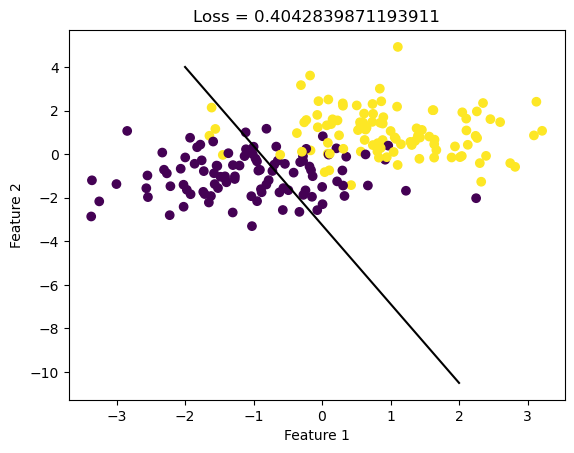

In [11]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = LR.draw_line(LR.initialW, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

title = plt.gca().set_title(f"Loss = {LR.loss_history[0]}")

We can then compare this to the visualization of the final weight vector (after performing gradient descent) - how it performed the linear classification, and its associated loss.

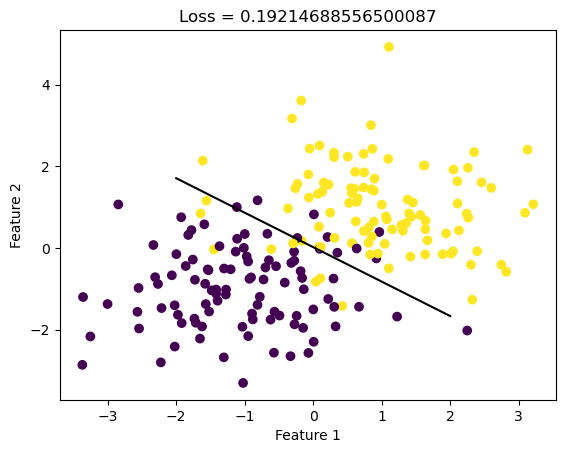

In [10]:
fig = plt.scatter(X[:,0], X[:,1], c = y)
fig = LR.draw_line(LR.w, -2, 2)

xlab = plt.xlabel("Feature 1")
ylab = plt.ylabel("Feature 2")

title = plt.gca().set_title(f"Loss = {LR.loss_history[-1]}")

Therefore, we can clearly see how the final set of weight vector (inclusive of <b>bias</b>) has a much less associated loss, and does a much better job at performing the linear classification. This can also be seen visually, by looking at the classification in the image above (with the final weight vector), and the one above it (with the initial - random - weight vector). 

# Explanation of Important Elements of the Gradient Descent Algorithm

